In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [2]:
results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"]==fund
    ]

    returns = (
        temp["daily_return"]
        .dropna()
    )

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = (
        returns[
            returns <= var_95
        ]
        .mean()
    )

    results.append([
        fund,
        var_95,
        cvar_95
    ])

var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [3]:
var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


Rolling Sharpe Ratio : 

In [4]:
key_funds = [
119551,
120503,
118632,
119092,
120841
]

In [5]:
import numpy as np

def rolling_sharpe(x):

    return (
        x.mean()
        /
        x.std()
    ) * np.sqrt(252)

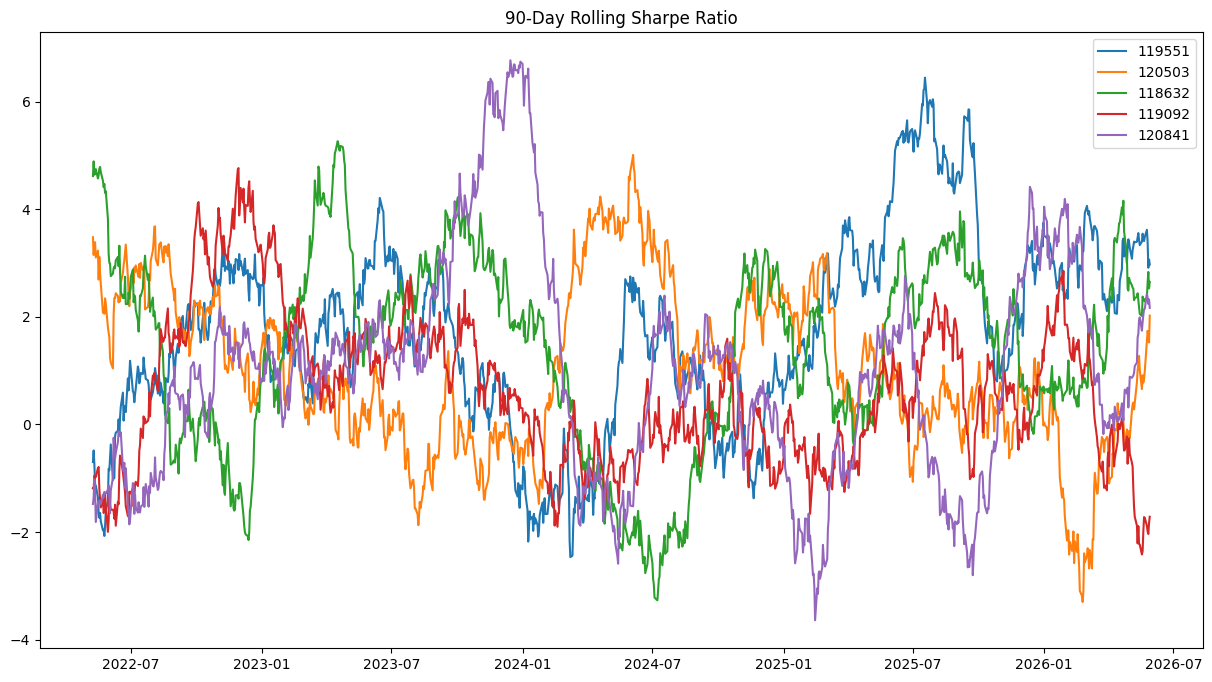

In [6]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(15,8)
)

for fund in key_funds:

    temp = (
        nav[
            nav["amfi_code"]==fund
        ]
        .copy()
    )

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .apply(
            rolling_sharpe,
            raw=False
        )
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "90-Day Rolling Sharpe Ratio"
)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Investor Cohort Analysis : 

In [7]:
tx = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

tx["transaction_date"] = pd.to_datetime(
    tx["transaction_date"]
)

In [8]:
first_tx = (
    tx.groupby("investor_id")
      ["transaction_date"]
      .min()
      .reset_index()
)

first_tx["cohort_year"] = (
    first_tx["transaction_date"]
    .dt.year
)

In [9]:
tx = tx.merge(
    first_tx[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

In [10]:
cohort_summary = (
    tx.groupby("cohort_year")
      .agg({
          "amount_inr":["mean","sum"]
      })
)

In [12]:
print(cohort_summary)

                amount_inr            
                      mean         sum
cohort_year                           
2024         107422.541832  3491125187
2025         109158.577061    30455243


In [13]:
top_funds = (
    tx.groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

In [14]:
print(top_funds)

    cohort_year  amfi_code  count
0          2024     100016    830
1          2024     100025    791
2          2024     100033    781
3          2024     101206    803
4          2024     101207    844
..          ...        ...    ...
75         2025     148568      9
76         2025     148569      6
77         2025     149322      5
78         2025     149323      8
79         2025     149324      6

[80 rows x 3 columns]


SIP Continuity Analysis

In [15]:
sip = tx[
    tx["transaction_type"]
    == "SIP"
].copy()

In [16]:
print(sip.head())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
5   INV001497       2024-01-01     101208              SIP        3295   
6   INV000786       2024-01-01     101208              SIP       15047   

            state       city city_tier age_group  gender  annual_income_lakh  \
0       Telangana  Hyderabad       T30       56+  Female                77.1   
2         Haryana  Faridabad       B30     36-45    Male                47.2   
3     Maharashtra     Mumbai       T30     36-45  Female                54.4   
5     Maharashtra     Mumbai       T30     36-45    Male                56.8   
6  Madhya Pradesh     Bhopal       B30     26-35    Male                17.9   

  payment_mode kyc_status  cohort_year  
0          UPI   Verified        

In [17]:
sip = sip.sort_values(
    ["investor_id",
     "transaction_date"]
)

In [18]:
sip["gap_days"] = (

sip.groupby("investor_id")
   ["transaction_date"]
   .diff()
   .dt.days

)

In [19]:
eligible = (
    sip.groupby("investor_id")
       .size()
)

eligible = eligible[
    eligible >= 6
].index

In [20]:
gap_analysis = (

sip[
    sip["investor_id"]
    .isin(eligible)
]

.groupby("investor_id")
["gap_days"]

.mean()

.reset_index()

)

In [21]:
gap_analysis["status"] = np.where(

gap_analysis["gap_days"] > 35,

"At Risk",

"Healthy"

)

In [24]:
print(gap_analysis['status'].unique())
print(gap_analysis.head())

['At Risk' 'Healthy']
  investor_id   gap_days   status
0   INV000004  85.400000  At Risk
1   INV000008  70.400000  At Risk
2   INV000010  64.800000  At Risk
3   INV000011  40.166667  At Risk
4   INV000012  57.000000  At Risk


Sector HHI Concentration

In [25]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [26]:
hhi = (

holdings.groupby(
    "amfi_code"
)

["weight_pct"]

.apply(
    lambda x:
    np.sum(
        (x/100)**2
    )
)

.reset_index(
    name="HHI"
)

)

Advanced Summary : 

In [27]:
perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

In [28]:
advanced_summary = (
    perf[
        [
            "amfi_code",
            "scheme_name",
            "fund_house",
            "category",
            "return_3yr_pct",
            "sharpe_ratio",
            "risk_grade"
        ]
    ]
    .merge(
        var_df,
        on="amfi_code",
        how="left"
    )
    .merge(
        hhi,
        on="amfi_code",
        how="left"
    )
)

In [29]:
advanced_summary.to_csv(
    "../data/processed/advanced_summary.csv",
    index=False
)